In [1]:
from google.colab import files
uploaded = files.upload()

Saving AEP_hourly.csv to AEP_hourly.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('AEP_hourly.csv')
print(df.head())
print(df.shape)
print(df.dtypes)

              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0
(121273, 2)
Datetime     object
AEP_MW      float64
dtype: object


Missing values: AEP_MW    0
dtype: int64
Date range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Total hours: 121269


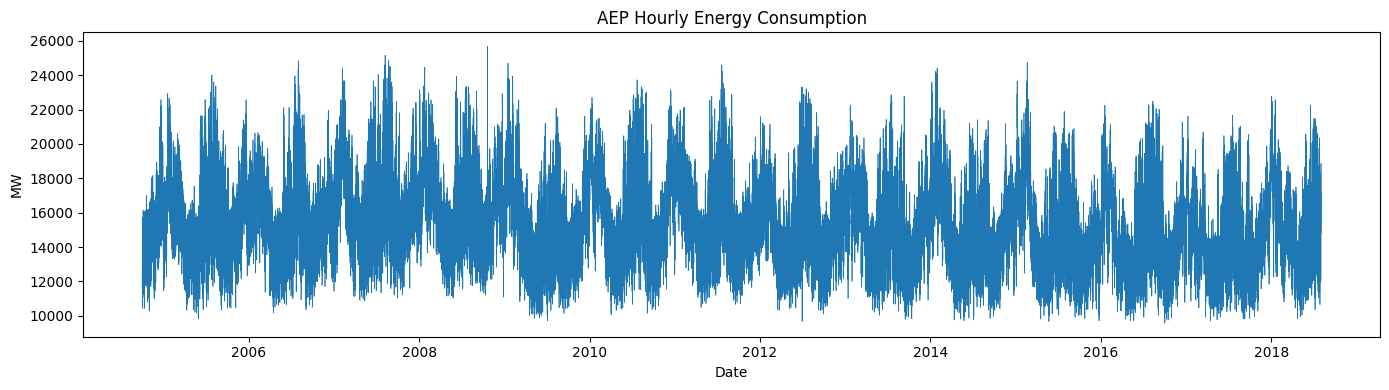

In [3]:
# Parse datetime and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

# Remove duplicates
df = df[~df.index.duplicated(keep='first')]

# Check for missing values
print("Missing values:", df.isnull().sum())
print("Date range:", df.index.min(), "to", df.index.max())
print("Total hours:", len(df))

# Plot the full series
plt.figure(figsize=(14,4))
plt.plot(df['AEP_MW'], linewidth=0.5)
plt.title('AEP Hourly Energy Consumption')
plt.ylabel('MW')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

Train size: 856
Test size: 90


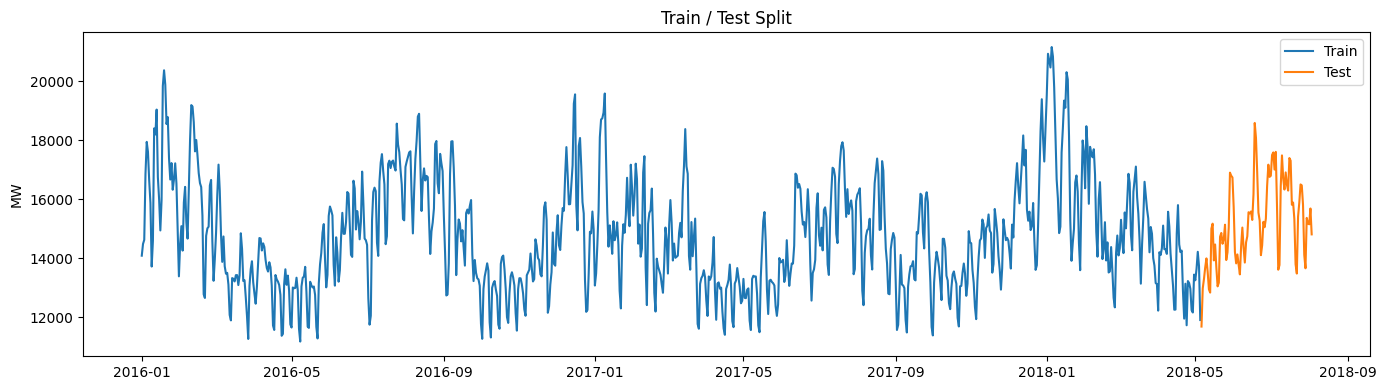

In [4]:
# Resample to daily average
df_daily = df.resample('D').mean()

# Use last 2 years for manageability
df_subset = df_daily['2016-01-01':'2018-08-03']

# Train/test split — last 90 days as test
train = df_subset.iloc[:-90]
test = df_subset.iloc[-90:]

print("Train size:", len(train))
print("Test size:", len(test))

# Plot train/test split
plt.figure(figsize=(14,4))
plt.plot(train['AEP_MW'], label='Train')
plt.plot(test['AEP_MW'], label='Test')
plt.title('Train / Test Split')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

Fitting ARIMA model...
ARIMA MAPE: 15.67%
ARIMA RMSE: 2844.99 MW


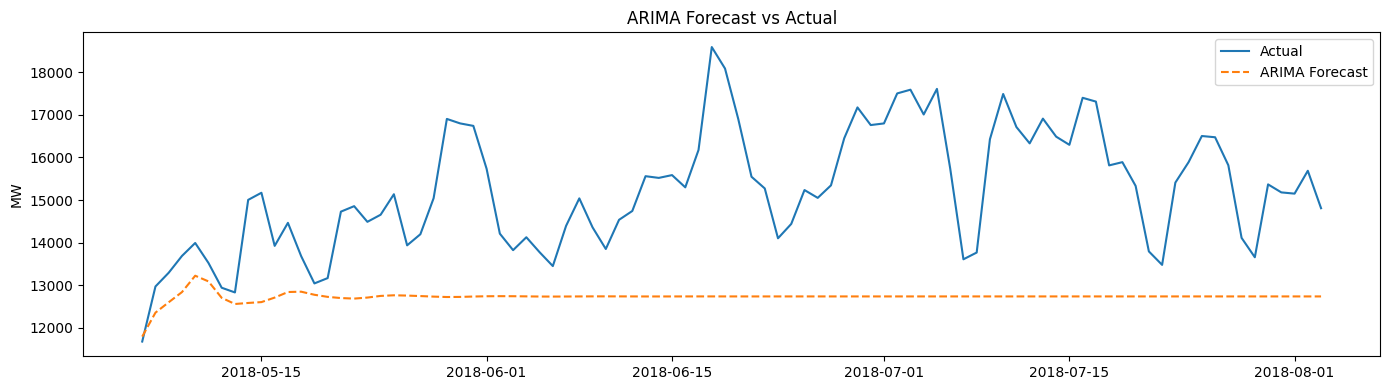

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Fit ARIMA model
print("Fitting ARIMA model...")
model = ARIMA(train['AEP_MW'], order=(5, 1, 0))
arima_fit = model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=90)

# Calculate metrics
arima_mape = mean_absolute_percentage_error(test['AEP_MW'], arima_forecast) * 100
arima_rmse = np.sqrt(mean_squared_error(test['AEP_MW'], arima_forecast))

print(f"ARIMA MAPE: {arima_mape:.2f}%")
print(f"ARIMA RMSE: {arima_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index, test['AEP_MW'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Normalize the data
train_values = train['AEP_MW'].values.reshape(-1, 1)
test_values = test['AEP_MW'].values.reshape(-1, 1)

mean = train_values.mean()
std = train_values.std()

train_norm = (train_values - mean) / std
test_norm = (test_values - mean) / std

# Create sequences
def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 30

X_train, y_train = create_sequences(train_norm, SEQ_LEN)
X_test, y_test = create_sequences(test_norm, SEQ_LEN)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# DataLoader
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Data ready.")

X_train shape: (826, 30, 1)
X_test shape: (60, 30, 1)
Data ready.


In [7]:
# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model_lstm = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Train
EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    model_lstm.train()
    epoch_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_lstm(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

print("Training complete.")

Using device: cpu
Epoch 10/50 - Loss: 6.1613
Epoch 20/50 - Loss: 5.7806
Epoch 30/50 - Loss: 4.4482
Epoch 40/50 - Loss: 3.9922
Epoch 50/50 - Loss: 3.5958
Training complete.


ARIMA MAPE: 15.67%  |  ARIMA RMSE: 2844.99 MW
LSTM  MAPE: 3.45%  |  LSTM  RMSE: 696.64 MW


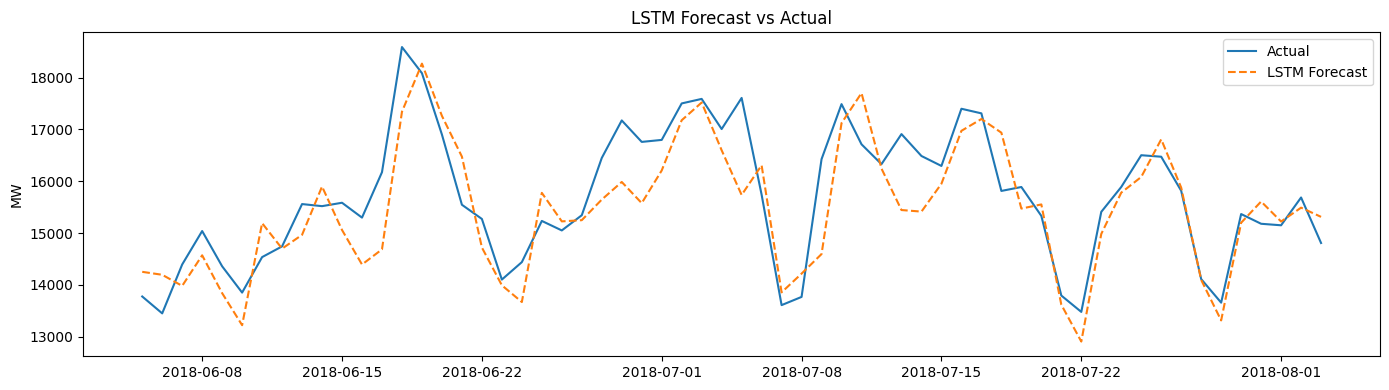

In [8]:
# Evaluate LSTM
model_lstm.eval()
with torch.no_grad():
    lstm_pred_norm = model_lstm(X_test_t.to(device)).cpu().numpy()

# Denormalize
lstm_pred = (lstm_pred_norm * std) + mean
actual = (y_test_t.numpy() * std) + mean

# Metrics
lstm_mape = mean_absolute_percentage_error(actual, lstm_pred) * 100
lstm_rmse = np.sqrt(mean_squared_error(actual, lstm_pred))

print(f"ARIMA MAPE: {arima_mape:.2f}%  |  ARIMA RMSE: {arima_rmse:.2f} MW")
print(f"LSTM  MAPE: {lstm_mape:.2f}%  |  LSTM  RMSE: {lstm_rmse:.2f} MW")

# Plot
plt.figure(figsize=(14,4))
plt.plot(test.index[SEQ_LEN:], actual, label='Actual')
plt.plot(test.index[SEQ_LEN:], lstm_pred, label='LSTM Forecast', linestyle='--')
plt.title('LSTM Forecast vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Define Transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2):
        super(TransformerModel, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

# Initialize
model_transformer = TransformerModel().to(device)
optimizer_t = torch.optim.Adam(model_transformer.parameters(), lr=0.001)

# Train
EPOCHS = 50
for epoch in range(EPOCHS):
    model_transformer.train()
    epoch_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_t.zero_grad()
        output = model_transformer(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer_t.step()
        epoch_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

print("Training complete.")

Epoch 10/50 - Loss: 7.5560
Epoch 20/50 - Loss: 7.1032
Epoch 30/50 - Loss: 7.1866
Epoch 40/50 - Loss: 7.1126
Epoch 50/50 - Loss: 6.7646
Training complete.


ARIMA       MAPE: 15.67%  |  RMSE: 2844.99 MW
LSTM        MAPE: 3.45%  |  RMSE: 696.64 MW
Transformer MAPE: 5.01%  |  RMSE: 1000.95 MW


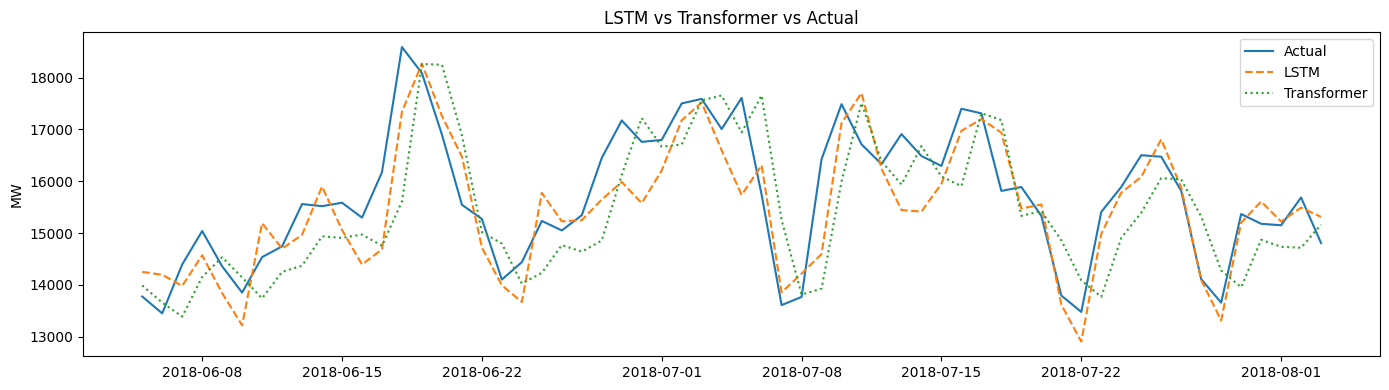

In [10]:
# Evaluate Transformer
model_transformer.eval()
with torch.no_grad():
    transformer_pred_norm = model_transformer(X_test_t.to(device)).cpu().numpy()

# Denormalize
transformer_pred = (transformer_pred_norm * std) + mean

# Metrics
transformer_mape = mean_absolute_percentage_error(actual, transformer_pred) * 100
transformer_rmse = np.sqrt(mean_squared_error(actual, transformer_pred))

print(f"ARIMA       MAPE: {arima_mape:.2f}%  |  RMSE: {arima_rmse:.2f} MW")
print(f"LSTM        MAPE: {lstm_mape:.2f}%  |  RMSE: {lstm_rmse:.2f} MW")
print(f"Transformer MAPE: {transformer_mape:.2f}%  |  RMSE: {transformer_rmse:.2f} MW")

# Plot all three
plt.figure(figsize=(14,4))
plt.plot(test.index[SEQ_LEN:], actual, label='Actual')
plt.plot(test.index[SEQ_LEN:], lstm_pred, label='LSTM', linestyle='--')
plt.plot(test.index[SEQ_LEN:], transformer_pred, label='Transformer', linestyle=':')
plt.title('LSTM vs Transformer vs Actual')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

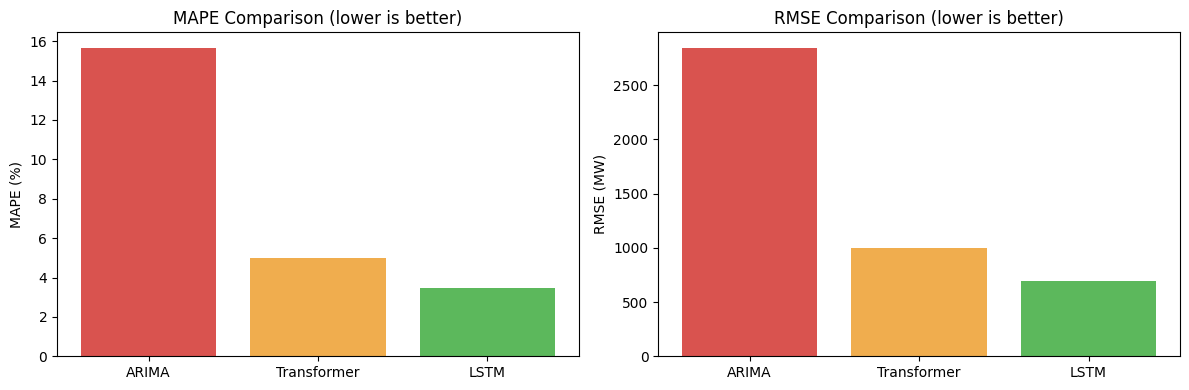


--- Project 3 Summary ---
Best model: LSTM with MAPE of 3.45%
Improvement over ARIMA baseline: 78.0%


In [11]:
# Final summary plot
models = ['ARIMA', 'Transformer', 'LSTM']
mapes = [arima_mape, transformer_mape, lstm_mape]
rmses = [arima_rmse, transformer_rmse, lstm_rmse]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(models, mapes, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax1.set_title('MAPE Comparison (lower is better)')
ax1.set_ylabel('MAPE (%)')

ax2.bar(models, rmses, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax2.set_title('RMSE Comparison (lower is better)')
ax2.set_ylabel('RMSE (MW)')

plt.tight_layout()
plt.show()

print("\n--- Project 3 Summary ---")
print(f"Best model: LSTM with MAPE of {lstm_mape:.2f}%")
print(f"Improvement over ARIMA baseline: {((arima_mape - lstm_mape)/arima_mape)*100:.1f}%")